## Imports

In [ ]:
from torch.utils.data import Dataset, DataLoader
import scipy.io as sio
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.datasets import MNIST
import pandas as pd
from time import sleep

%matplotlib inline

## Dataset: Flower102

### Read and Examine Data (2 points)

**Label Reference** 📕: https://www.robots.ox.ac.uk/~vgg/data/flowers/102/categories.html

In [ ]:
# DONT MODIFY THIS CODE CELL
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
!tar -xvzf /content/102flowers.tgz
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat

Streaming output truncated to the last 5000 lines.
jpg/image_05112.jpg
jpg/image_05638.jpg
jpg/image_00053.jpg
jpg/image_02451.jpg
jpg/image_05857.jpg
jpg/image_08033.jpg
jpg/image_03902.jpg
jpg/image_07494.jpg
jpg/image_02357.jpg
jpg/image_05496.jpg
jpg/image_04496.jpg
jpg/image_07538.jpg
jpg/image_01801.jpg
jpg/image_00326.jpg
jpg/image_07644.jpg
jpg/image_01199.jpg
jpg/image_01168.jpg
jpg/image_07020.jpg
jpg/image_05006.jpg
jpg/image_03484.jpg
jpg/image_02825.jpg
jpg/image_04549.jpg
jpg/image_02011.jpg
jpg/image_04360.jpg
jpg/image_06847.jpg
jpg/image_07695.jpg
jpg/image_03540.jpg
jpg/image_08058.jpg
jpg/image_01230.jpg
jpg/image_00096.jpg
jpg/image_01517.jpg
jpg/image_07640.jpg
jpg/image_04883.jpg
jpg/image_06145.jpg
jpg/image_07742.jpg
jpg/image_00604.jpg
jpg/image_00743.jpg
jpg/image_01920.jpg
jpg/image_00104.jpg
jpg/image_01503.jpg
jpg/image_02910.jpg
jpg/image_01407.jpg
jpg/image_06754.jpg
jpg/image_07184.jpg
jpg/image_06889.jpg
jpg/image_05796.jpg
jpg/image_05724.jpg
jpg/image

In [ ]:
# DONT MODIFY THIS CODE CELL
labels = sio.loadmat('imagelabels.mat')['labels']

In [ ]:
labels

array([[77, 77, 77, ..., 62, 62, 62]], dtype=uint8)

In [ ]:
import os

imageslist = os.listdir('/content/jpg')
imageslist.sort()

In [ ]:
labels_sz = len(labels[0])
labels_sz

8189

In [ ]:
train_labels = labels[0][:int (0.8*labels_sz)]
test_labels = labels[0][ int (0.8*labels_sz):]


In [ ]:
len(test_labels)

1638

In [ ]:
len(train_labels)

6551

In [ ]:
labels_sz

8189

In [ ]:
DF_train = pd.DataFrame(train_labels)

DF_test = pd.DataFrame(test_labels)
lisitingimages=list(zip( imageslist, labels[0]))

In [ ]:
df = pd.DataFrame(lisitingimages , columns=['Names', 'Labels'])


In [ ]:
df

,Names,Labels
0,image_00001.jpg,77
1,image_00002.jpg,77
2,image_00003.jpg,77
3,image_00004.jpg,77
4,image_00005.jpg,77
...,...,...
8184,image_08185.jpg,62
8185,image_08186.jpg,62
8186,image_08187.jpg,62
8187,image_08188.jpg,62


### Custom Dataset (4 points)

**Start Coding Here...** 👨‍💻👩‍💻

In [ ]:
#starting to customize my dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((28,28))

])
class MyCustomDataset(Dataset):
  def __init__(self, labels_file, image_path, transform = None):
    self.labels_file = labels_file
    self.image_path = image_path
    self.transform = transform

  def __len__(self):
    return len(self.labels_file)

  def __getitem__(self, idx):
    image_name = self.labels_file["Names"].iloc[idx]
    label = self.labels_file["Labels"].iloc[idx]

    im = Image.open(f"{self.image_path}/{image_name}").convert("L")
    im = np.array(im)

    if self.transform:
      im = self.transform(im)

    # return {"Data": im, "Label":label}
    return im, label





In [ ]:
print(MyCustomDataset)


<class '__main__.MyCustomDataset'>


In [ ]:
print(MyCustomDataset.__getitem__)


<function MyCustomDataset.__getitem__ at 0x79e652fd64d0>


In [ ]:
train_dataset = MyCustomDataset(df, "/content/jpg", transform = transform)
test_dataset = MyCustomDataset(df, "/content/jpg", transform = transform)

In [ ]:
len(train_dataset)

8189

In [ ]:
im[0].shape

torch.Size([28, 28])

In [ ]:
im, label = test_dataset[0]
im.shape

torch.Size([1, 28, 28])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size= 32, shuffle=True)

## CNN Model (4 points)

In [ ]:
# CNN model

# structure = conv2 layer, max pool, conv2 layer, max pool, linear layer, linear layer
class CNN(nn.Module):
  def __init__(self, input, output):
    super().__init__()

    # parameters = input channel num, output channel num, filter size, stride size, padding size
    self.conv1 = nn.Conv2d(input,20,3,1,1) # 2d since we're dealing with pics
    self.conv2 = nn.Conv2d(20,50,3,1,1)
    self.linear1 = nn.Linear(50 * 7 * 7 , 100) # from forward passing
    self.linear2 = nn.Linear(100,output) # we only have 10 numbers -> 10 classes

  def forward(self, x):
    # feature extractor part
    # x = (1,28,28)
    x = self.conv1(x)
    x = torch.relu(x)

    # x = (20,28,28) - > conv layer only chaneged the num of channels here
    x = F.max_pool2d(x, (2,2)) # 2,2 size of the max pool filter

    # x = (20,14,14)
    x = self.conv2(x)
    x = torch.relu(x)

    # x = (50,14,14)
    x = F.max_pool2d(x, (2,2))

    # x = (50,7,7)
    #flatten it before sending it to the linear layers
    x = x.view(-1, 50* 7 * 7)
    x = self.linear1(x)
    x = torch.relu(x)
    x = self.linear2(x)

    # x = torch.softmax(x)  we dont add softmax because it is used in cross entropy loss
    return x

In [ ]:
# Define the device to use GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# CNN model

#1 is the number of input channels (gray scale), 10 is the number of classes
model2 = CNN(1, 103).to(device)

num_epochs = 10
lr = 0.1
momentum = 0.5

opt = optim.SGD(model2.parameters(), lr = lr, momentum = momentum) # define optimizer

ls = []
for i in range(num_epochs):
  total_loss = 0
  for batch in train_loader:
    X,y = batch[0].to(device), batch[1].to(device)

    # forward pass
    yhat = model2(X)

    # calculate loss
    loss = F.cross_entropy(yhat, y)

    # backward passing
    opt.zero_grad()
    loss.backward()
    opt.step()
    total_loss += loss.item()

  ls.append(total_loss/len(train_loader))



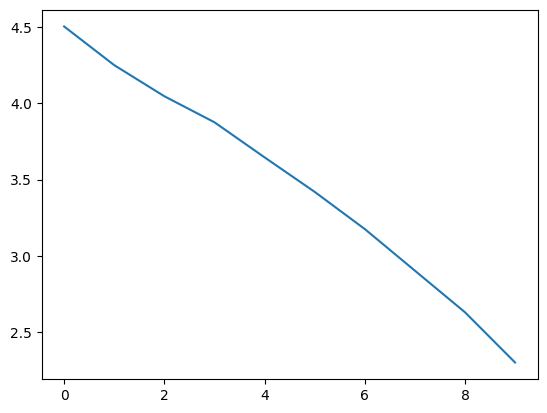

In [ ]:
plt.plot(ls)

In [ ]:
# Accuracy function for NN
def accuracy(model, train_loader):

  # all techniques used for training (e.g. dropouts, batch normalization) will be freezed during eval mode
  model.eval()

  # no_grad() disables gradient calculations to reduce memory consumptions (basically makes it faster)
  with torch.no_grad():
    correct  = 0
    total = 0
    for X, y in test_loader:
      X, y = X.to(device), y.to(device)

      output = model(X)
      loss = F.cross_entropy(output, y)
      pred = torch.argmax(output, dim = 1)
      correct += sum(pred == y)
      total += len(y)

  print(f"The accuracy is {correct.item()/total * 100 :.2f}% \n")

In [ ]:
accuracy(model2, test_loader) # CNN acc

The accuracy is 49.58% 



**Start Coding Here...** 👨‍💻👩‍💻